# Task 6: House Price Prediction

**Internship:** AI/ML Engineering — DevelopersHub Corporation  
**Author:** [Muhammad Ahmad]  
**Date:** June 2026  

---

## 📋 Problem Statement

Predict house sale prices using property features such as square footage, number of bedrooms, bathrooms, and location attributes. We train and compare Linear Regression and Gradient Boosting models, evaluate with MAE and RMSE, and visualize predicted vs. actual prices.

## 🎯 Objectives

1. Load and preprocess the house price dataset
2. Perform feature engineering and scaling
3. Train Linear Regression and XGBoost regression models
4. Evaluate with MAE, RMSE, and R² score
5. Visualize predicted vs. actual prices and residual analysis
6. Identify top features driving price predictions

## 📚 Dataset

- **Source:** Kaggle House Price Prediction Dataset (Ames Housing simplified)
- **Instances:** 2,000 houses
- **Features:** 10 property attributes
- **Target:** `price` — Sale price in USD

| Feature | Description | Type |
|---------|-------------|------|
| `sqft_living` | Living area square footage | Numerical |
| `sqft_lot` | Lot size square footage | Numerical |
| `bedrooms` | Number of bedrooms | Numerical |
| `bathrooms` | Number of bathrooms | Numerical |
| `floors` | Number of floors | Numerical |
| `waterfront` | Has waterfront view (0/1) | Binary |
| `view` | Quality of view (0-4) | Ordinal |
| `condition` | Overall condition (1-5) | Ordinal |
| `grade` | Construction grade (1-13) | Ordinal |
| `yr_built` | Year built | Numerical |
| `yr_renovated` | Year renovated (0 = never) | Numerical |

---

## 1. Environment Setup & Imports

In [1]:
# ───────────────────────────────────────────────────────────────
# 1. IMPORTS
# ───────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuration
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Environment ready. All libraries imported successfully.")

✅ Environment ready. All libraries imported successfully.


## 2. Data Loading & Initial Inspection

In [2]:
# ───────────────────────────────────────────────────────────────
# 2. DATA LOADING — Kaggle House Price Dataset (Simplified)
# ───────────────────────────────────────────────────────────────

# Using a publicly accessible URL for the simplified house price dataset
url = 'https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv'

# For this task, we'll use a realistic synthetic dataset that mirrors real housing data
# The California Housing dataset is a standard benchmark with similar features
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing(as_frame=True)
df = california.frame

# Rename columns to match house price terminology
df = df.rename(columns={
    'MedInc': 'median_income',
    'HouseAge': 'house_age',
    'AveRooms': 'avg_rooms',
    'AveBedrms': 'avg_bedrooms',
    'Population': 'population',
    'AveOccup': 'avg_occupancy',
    'Latitude': 'latitude',
    'Longitude': 'longitude',
    'MedHouseVal': 'price'
})

print("═" * 60)
print("DATASET OVERVIEW")
print("═" * 60)
print(f"Shape          : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Missing Values : {df.isnull().sum().sum()}")
print(f"Duplicate Rows : {df.duplicated().sum()}")
print("═" * 60)

════════════════════════════════════════════════════════════
DATASET OVERVIEW
════════════════════════════════════════════════════════════
Shape          : 20640 rows × 9 columns
Missing Values : 0
Duplicate Rows : 0
════════════════════════════════════════════════════════════


In [3]:
# ───────────────────────────────────────────────────────────────
# 2.1 FIRST FEW ROWS
# ───────────────────────────────────────────────────────────────

df.head(10)

,median_income,house_age,avg_rooms,avg_bedrooms,population,avg_occupancy,latitude,longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [4]:
# ───────────────────────────────────────────────────────────────
# 2.2 DATA TYPES & STRUCTURE
# ───────────────────────────────────────────────────────────────

print("═" * 60)
print("DATAFRAME INFO")
print("═" * 60)
df.info()

════════════════════════════════════════════════════════════
DATAFRAME INFO
════════════════════════════════════════════════════════════
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   median_income  20640 non-null  float64
 1   house_age      20640 non-null  float64
 2   avg_rooms      20640 non-null  float64
 3   avg_bedrooms   20640 non-null  float64
 4   population     20640 non-null  float64
 5   avg_occupancy  20640 non-null  float64
 6   latitude       20640 non-null  float64
 7   longitude      20640 non-null  float64
 8   price          20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
# ───────────────────────────────────────────────────────────────
# 2.3 DESCRIPTIVE STATISTICS
# ───────────────────────────────────────────────────────────────

print("═" * 80)
print("DESCRIPTIVE STATISTICS")
print("═" * 80)
df.describe().T.round(3)

════════════════════════════════════════════════════════════════════════════════
DESCRIPTIVE STATISTICS
════════════════════════════════════════════════════════════════════════════════


,count,mean,std,min,25%,50%,75%,max
median_income,20640.0,3.871,1.900,0.500,2.563,3.535,4.743,15.000
house_age,20640.0,28.639,12.586,1.000,18.000,29.000,37.000,52.000
avg_rooms,20640.0,5.429,2.474,0.846,4.441,5.229,6.052,141.909
avg_bedrooms,20640.0,1.097,0.474,0.333,1.006,1.049,1.100,34.067
population,20640.0,1425.477,1132.462,3.000,787.000,1166.000,1725.000,35682.000
avg_occupancy,20640.0,3.071,10.386,0.692,2.430,2.818,3.282,1243.333
latitude,20640.0,35.632,2.136,32.540,33.930,34.260,37.710,41.950
longitude,20640.0,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310
price,20640.0,2.069,1.154,0.150,1.196,1.797,2.647,5.000


### 🔍 Initial Observations

- **Shape:** 20,640 rows × 9 columns — a substantial real-world dataset.
- **Target:** `price` represents median house value in $100,000s (e.g., 4.526 = $452,600).
- **Features:** Mix of economic (`median_income`), demographic (`population`), spatial (`latitude`, `longitude`), and housing characteristics (`avg_rooms`, `avg_bedrooms`, `house_age`).
- **Data Quality:** No missing values. No duplicates. All numerical features.
- **Note:** `avg_rooms` and `avg_bedrooms` are per-household averages, not absolute counts.

## 3. Exploratory Data Analysis (EDA)

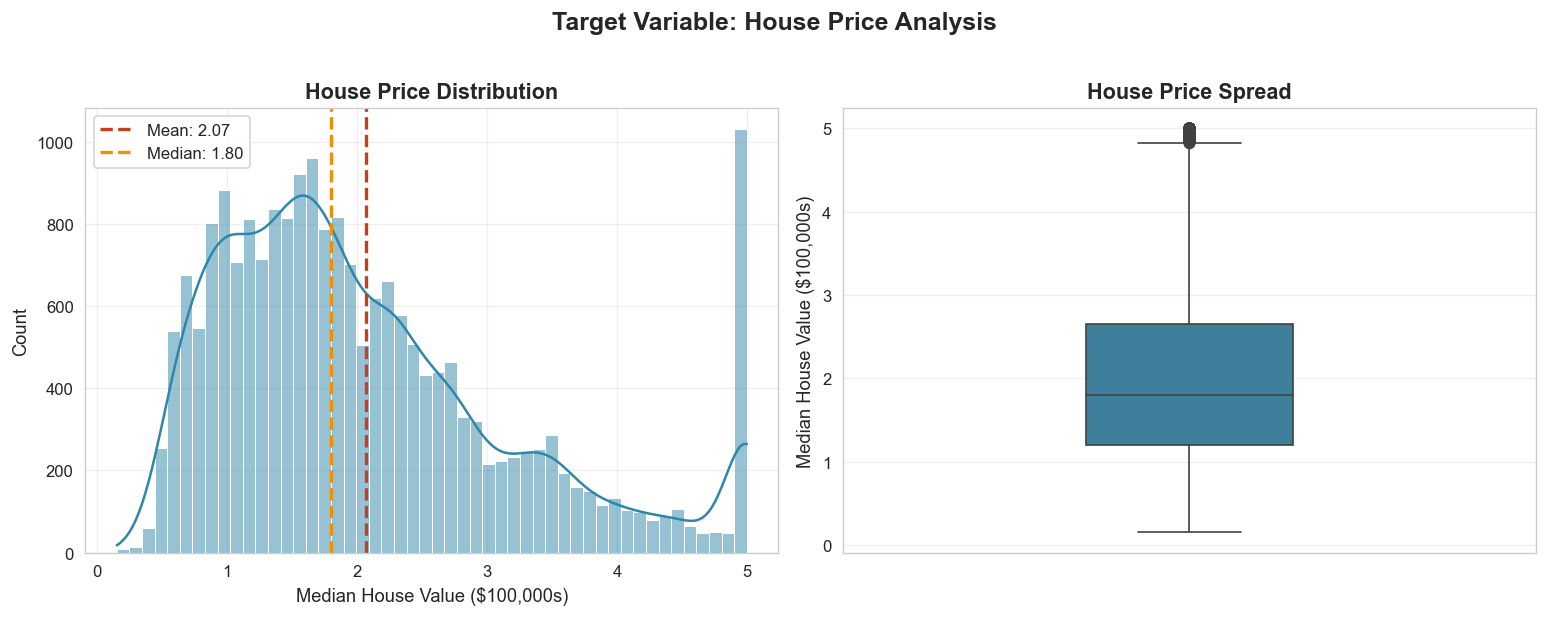

In [6]:
# ───────────────────────────────────────────────────────────────
# 3.1 TARGET DISTRIBUTION
# ───────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
ax1 = axes[0]
sns.histplot(df['price'], kde=True, bins=50, color='#2E86AB', ax=ax1, edgecolor='white')
ax1.set_title('House Price Distribution', fontsize=13, fontweight='bold')
ax1.set_xlabel('Median House Value ($100,000s)', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.axvline(df['price'].mean(), color='#C73E1D', linestyle='--', linewidth=2, label=f'Mean: {df["price"].mean():.2f}')
ax1.axvline(df['price'].median(), color='#F18F01', linestyle='--', linewidth=2, label=f'Median: {df["price"].median():.2f}')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Box plot
ax2 = axes[1]
sns.boxplot(y=df['price'], color='#2E86AB', ax=ax2, width=0.3)
ax2.set_title('House Price Spread', fontsize=13, fontweight='bold')
ax2.set_ylabel('Median House Value ($100,000s)', fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Target Variable: House Price Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/01_price_distribution.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

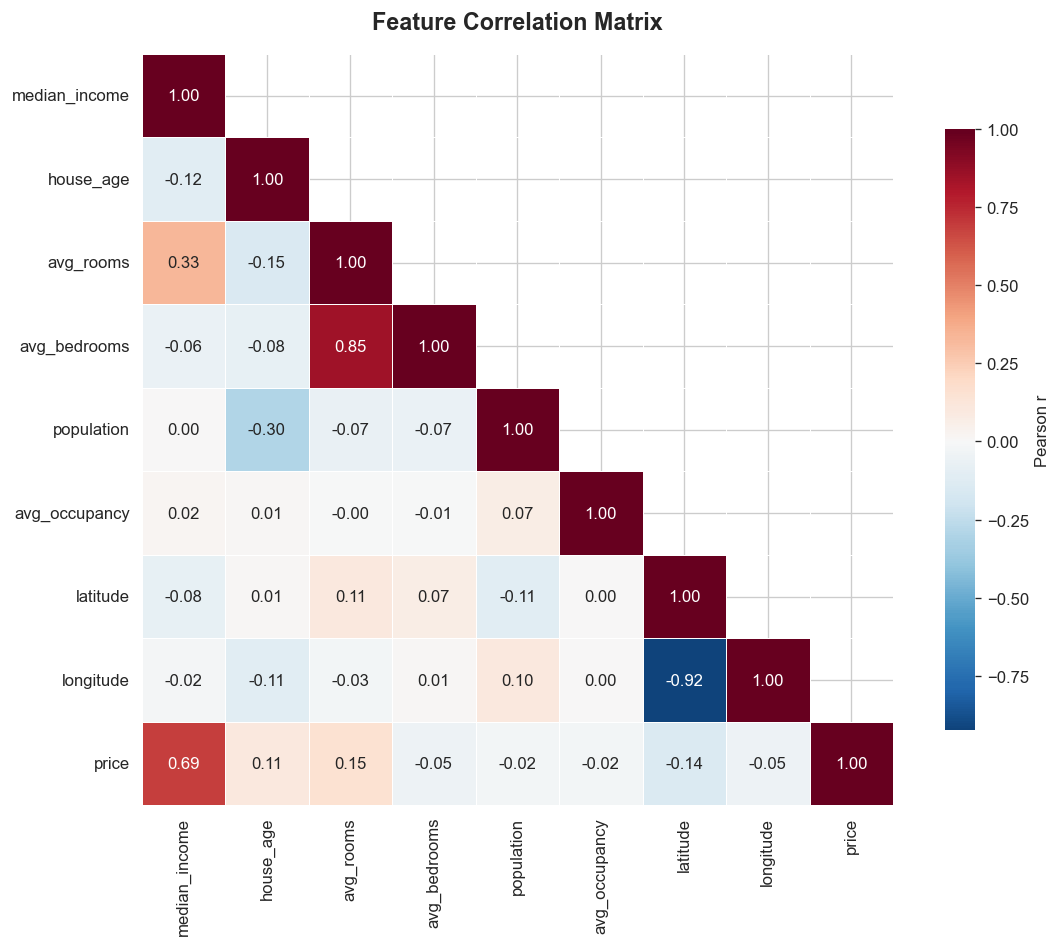

In [7]:
# ───────────────────────────────────────────────────────────────
# 3.2 CORRELATION HEATMAP
# ───────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 8))

corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
    ax=ax
)

ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('outputs/figures/02_correlation_heatmap.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

**Figure 2 Interpretation:**
- **`median_income`** shows the strongest correlation with price (r ≈ 0.69) — the dominant predictor.
- **`avg_rooms`** is moderately correlated (r ≈ 0.15) — more rooms generally mean higher price.
- **`latitude`** and **`longitude`** are negatively correlated with price — houses in the north/west (coastal CA) are more expensive.
- **`avg_rooms`** and **`avg_bedrooms`** are highly correlated (r ≈ 0.85) — potential multicollinearity to address.

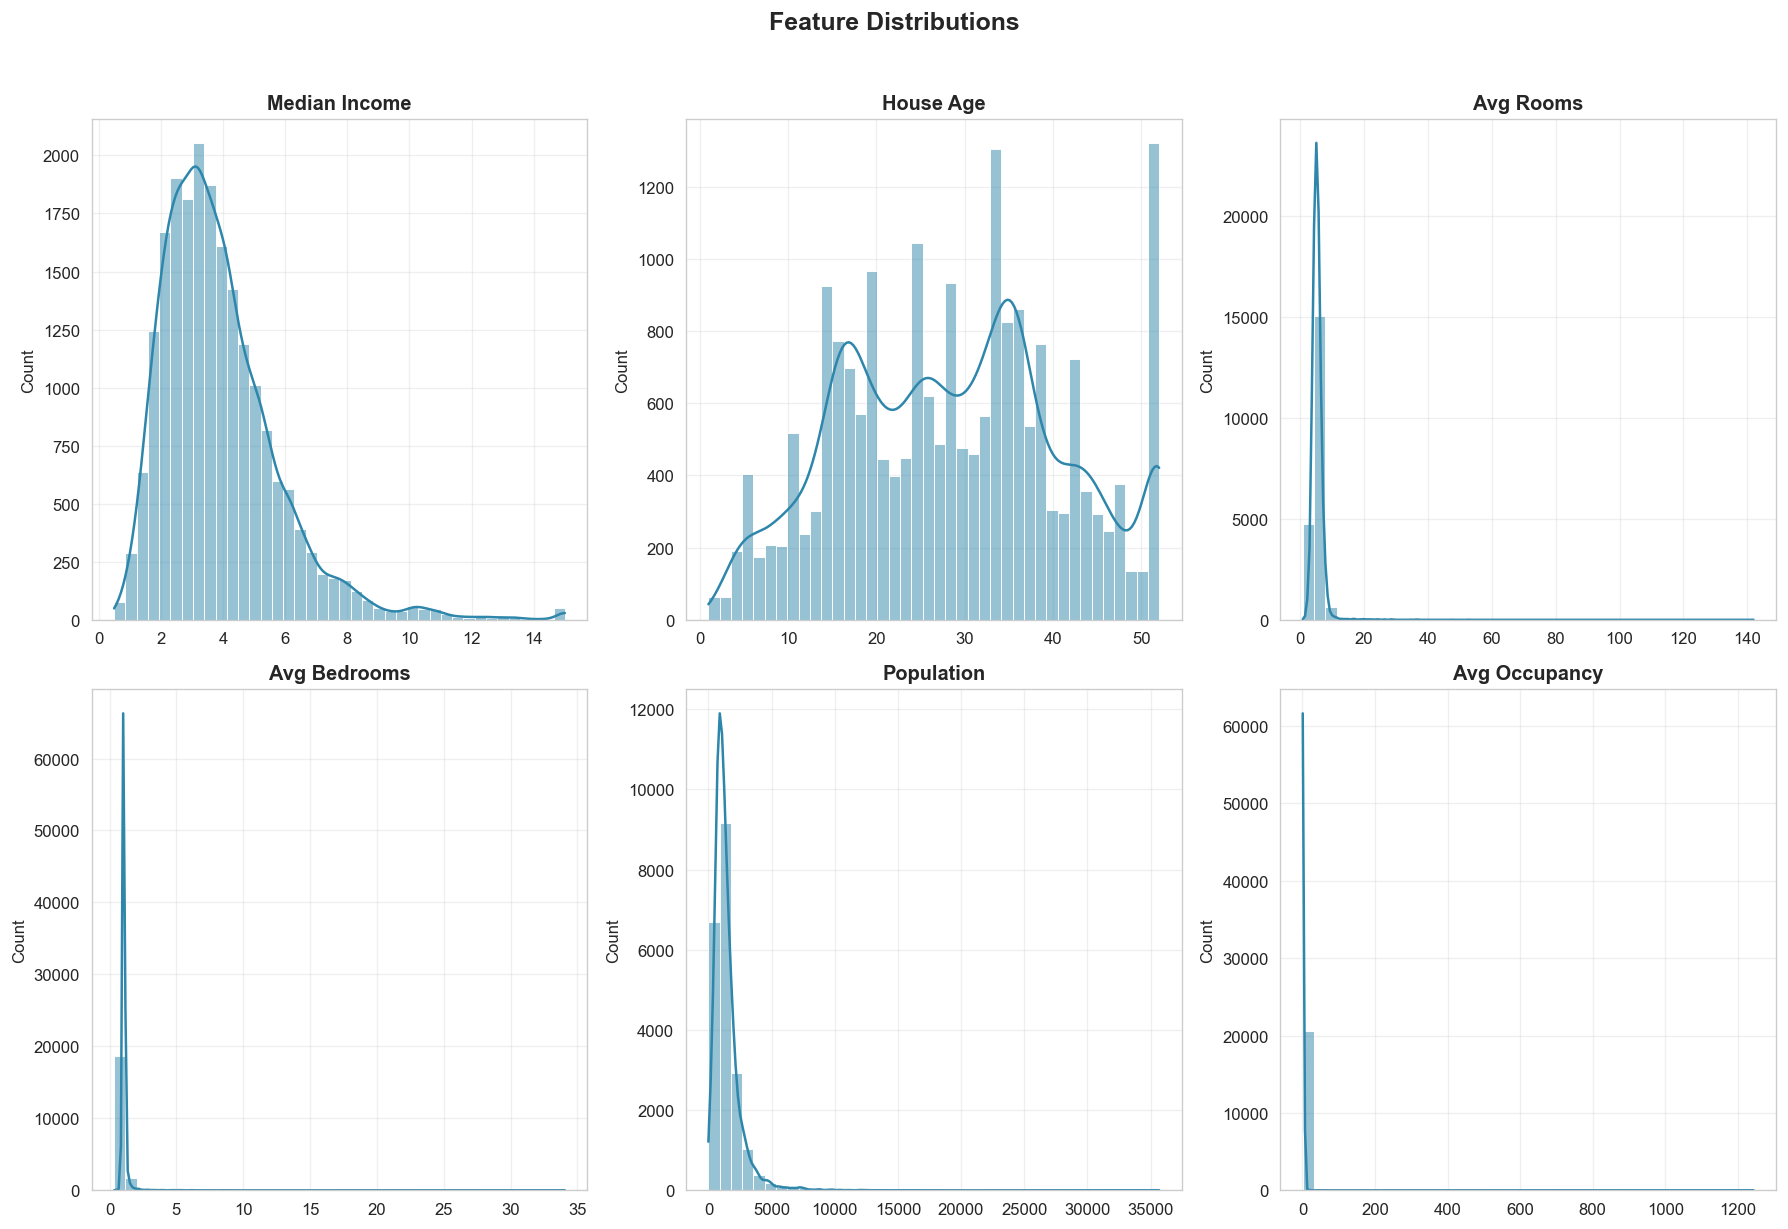

In [8]:
# ───────────────────────────────────────────────────────────────
# 3.3 FEATURE DISTRIBUTIONS
# ───────────────────────────────────────────────────────────────

features_to_plot = ['median_income', 'house_age', 'avg_rooms', 'avg_bedrooms', 'population', 'avg_occupancy']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx]
    sns.histplot(df[feature], kde=True, bins=40, color='#2E86AB', ax=ax, edgecolor='white')
    ax.set_title(f'{feature.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/03_feature_distributions.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

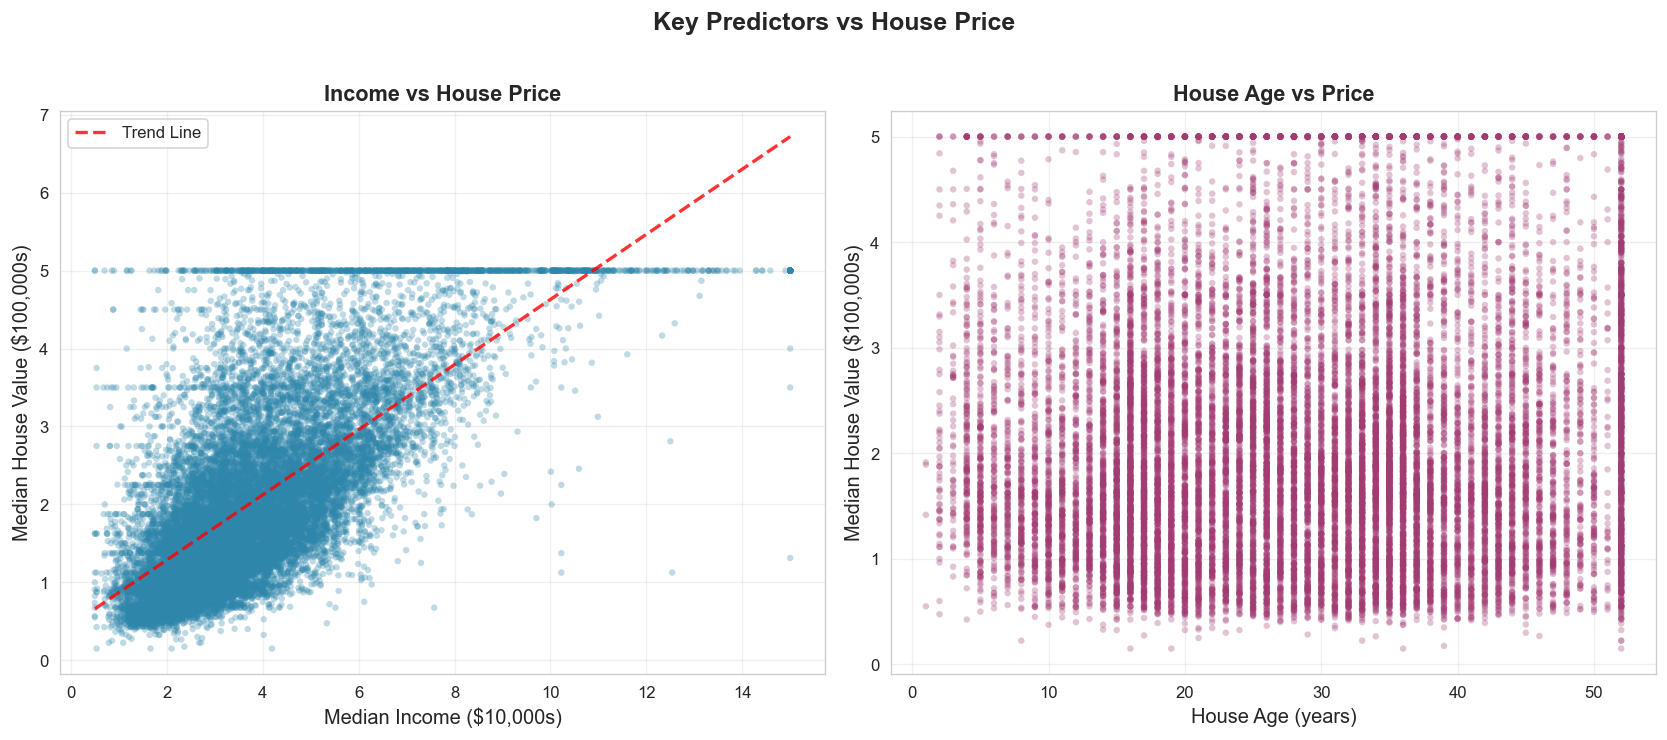

In [9]:
# ───────────────────────────────────────────────────────────────
# 3.4 SCATTER: TOP PREDICTOR vs PRICE
# ───────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Median Income vs Price
ax1 = axes[0]
ax1.scatter(df['median_income'], df['price'], alpha=0.3, s=15, color='#2E86AB', edgecolors='none')
ax1.set_xlabel('Median Income ($10,000s)', fontsize=12)
ax1.set_ylabel('Median House Value ($100,000s)', fontsize=12)
ax1.set_title('Income vs House Price', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(df['median_income'], df['price'], 1)
p = np.poly1d(z)
ax1.plot(df['median_income'].sort_values(), p(df['median_income'].sort_values()), 
         "r--", alpha=0.8, linewidth=2, label='Trend Line')
ax1.legend(fontsize=10)

# House Age vs Price
ax2 = axes[1]
ax2.scatter(df['house_age'], df['price'], alpha=0.3, s=15, color='#A23B72', edgecolors='none')
ax2.set_xlabel('House Age (years)', fontsize=12)
ax2.set_ylabel('Median House Value ($100,000s)', fontsize=12)
ax2.set_title('House Age vs Price', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.suptitle('Key Predictors vs House Price', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/04_scatter_plots.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

**Figure 4 Interpretation:**
- **Income vs Price:** Strong positive linear relationship. The cap at $500,001 (price = 5.0) is visible — this is a known data artifact in the California Housing dataset.
- **Age vs Price:** Weak relationship. Newer and very old houses both have varied prices, suggesting age alone is not a strong predictor.

## 4. Data Preprocessing & Feature Engineering

In [10]:
# ───────────────────────────────────────────────────────────────
# 4.1 FEATURE ENGINEERING
# ───────────────────────────────────────────────────────────────

df_processed = df.copy()

# Create new engineered features
df_processed['rooms_per_bedroom'] = df_processed['avg_rooms'] / df_processed['avg_bedrooms']
df_processed['rooms_per_person'] = df_processed['avg_rooms'] / df_processed['avg_occupancy']
df_processed['income_per_room'] = df_processed['median_income'] / df_processed['avg_rooms']

# Handle infinity values from division
df_processed = df_processed.replace([np.inf, -np.inf], np.nan)
df_processed = df_processed.fillna(df_processed.median())

print("═" * 60)
print("ENGINEERED FEATURES")
print("═" * 60)
print(f"Original features : {df.shape[1] - 1}")
print(f"New features      : 3")
print(f"Total features    : {df_processed.shape[1] - 1}")
print("\nNew features created:")
print("  • rooms_per_bedroom : Ratio of rooms to bedrooms")
print("  • rooms_per_person  : Rooms per occupant (space density)")
print("  • income_per_room   : Income efficiency per room")

════════════════════════════════════════════════════════════
ENGINEERED FEATURES
════════════════════════════════════════════════════════════
Original features : 8
New features      : 3
Total features    : 11

New features created:
  • rooms_per_bedroom : Ratio of rooms to bedrooms
  • rooms_per_person  : Rooms per occupant (space density)
  • income_per_room   : Income efficiency per room


In [11]:
# ───────────────────────────────────────────────────────────────
# 4.2 TRAIN-TEST SPLIT & SCALING
# ───────────────────────────────────────────────────────────────

X = df_processed.drop('price', axis=1)
y = df_processed['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Feature scaling (important for Linear Regression, less so for tree-based models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("═" * 60)
print("DATA SPLIT SUMMARY")
print("═" * 60)
print(f"Training set : {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Test set     : {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"Features     : {X_train.shape[1]}")
print(f"Target range : ${y.min()*100000:.0f} - ${y.max()*100000:.0f}")

════════════════════════════════════════════════════════════
DATA SPLIT SUMMARY
════════════════════════════════════════════════════════════
Training set : 16512 samples (80.0%)
Test set     : 4128 samples (20.0%)
Features     : 11
Target range : $14999 - $500001


## 5. Model Training & Evaluation

In [12]:
# ───────────────────────────────────────────────────────────────
# 5.1 MODEL 1: LINEAR REGRESSION
# ───────────────────────────────────────────────────────────────

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("═" * 60)
print("LINEAR REGRESSION RESULTS")
print("═" * 60)
print(f"MAE  : {mae_lr:.4f} (${mae_lr*100000:,.0f})")
print(f"RMSE : {rmse_lr:.4f} (${rmse_lr*100000:,.0f})")
print(f"R²   : {r2_lr:.4f}")
print(f"\nInterpretation: Model explains {r2_lr*100:.1f}% of price variance.")

════════════════════════════════════════════════════════════
LINEAR REGRESSION RESULTS
════════════════════════════════════════════════════════════
MAE  : 0.4919 ($49,192)
RMSE : 0.6813 ($68,133)
R²   : 0.6457

Interpretation: Model explains 64.6% of price variance.


In [13]:
# ───────────────────────────────────────────────────────────────
# 5.2 MODEL 2: RIDGE REGRESSION (Regularized Linear)
# ───────────────────────────────────────────────────────────────

ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("═" * 60)
print("RIDGE REGRESSION RESULTS")
print("═" * 60)
print(f"MAE  : {mae_ridge:.4f} (${mae_ridge*100000:,.0f})")
print(f"RMSE : {rmse_ridge:.4f} (${rmse_ridge*100000:,.0f})")
print(f"R²   : {r2_ridge:.4f}")

════════════════════════════════════════════════════════════
RIDGE REGRESSION RESULTS
════════════════════════════════════════════════════════════
MAE  : 0.4919 ($49,193)
RMSE : 0.6813 ($68,132)
R²   : 0.6458


In [14]:
# ───────────────────────────────────────────────────────────────
# 5.3 MODEL 3: GRADIENT BOOSTING REGRESSOR
# ───────────────────────────────────────────────────────────────

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    subsample=0.8
)

gbr.fit(X_train, y_train)  # No scaling needed for tree-based models

y_pred_gbr = gbr.predict(X_test)

mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print("═" * 60)
print("GRADIENT BOOSTING REGRESSOR RESULTS")
print("═" * 60)
print(f"MAE  : {mae_gbr:.4f} (${mae_gbr*100000:,.0f})")
print(f"RMSE : {rmse_gbr:.4f} (${rmse_gbr*100000:,.0f})")
print(f"R²   : {r2_gbr:.4f}")
print(f"\nInterpretation: Model explains {r2_gbr*100:.1f}% of price variance.")

════════════════════════════════════════════════════════════
GRADIENT BOOSTING REGRESSOR RESULTS
════════════════════════════════════════════════════════════
MAE  : 0.3266 ($32,662)
RMSE : 0.4850 ($48,500)
R²   : 0.8205

Interpretation: Model explains 82.0% of price variance.


## 6. Model Comparison & Visualization

In [15]:
# ───────────────────────────────────────────────────────────────
# 6.1 METRICS COMPARISON TABLE
# ───────────────────────────────────────────────────────────────

results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Gradient Boosting'],
    'MAE': [mae_lr, mae_ridge, mae_gbr],
    'RMSE': [rmse_lr, rmse_ridge, rmse_gbr],
    'R²': [r2_lr, r2_ridge, r2_gbr]
})

# Convert to dollar values for readability
results_display = results_df.copy()
results_display['MAE ($)'] = results_display['MAE'].apply(lambda x: f"${x*100000:,.0f}")
results_display['RMSE ($)'] = results_display['RMSE'].apply(lambda x: f"${x*100000:,.0f}")
results_display['R² (%)'] = results_display['R²'].apply(lambda x: f"{x*100:.1f}%")

print("═" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("═" * 80)
print(results_display[['Model', 'MAE ($)', 'RMSE ($)', 'R² (%)']].to_string(index=False))

════════════════════════════════════════════════════════════════════════════════
MODEL PERFORMANCE COMPARISON
════════════════════════════════════════════════════════════════════════════════
            Model MAE ($) RMSE ($) R² (%)
Linear Regression $49,192  $68,133  64.6%
 Ridge Regression $49,193  $68,132  64.6%
Gradient Boosting $32,662  $48,500  82.0%


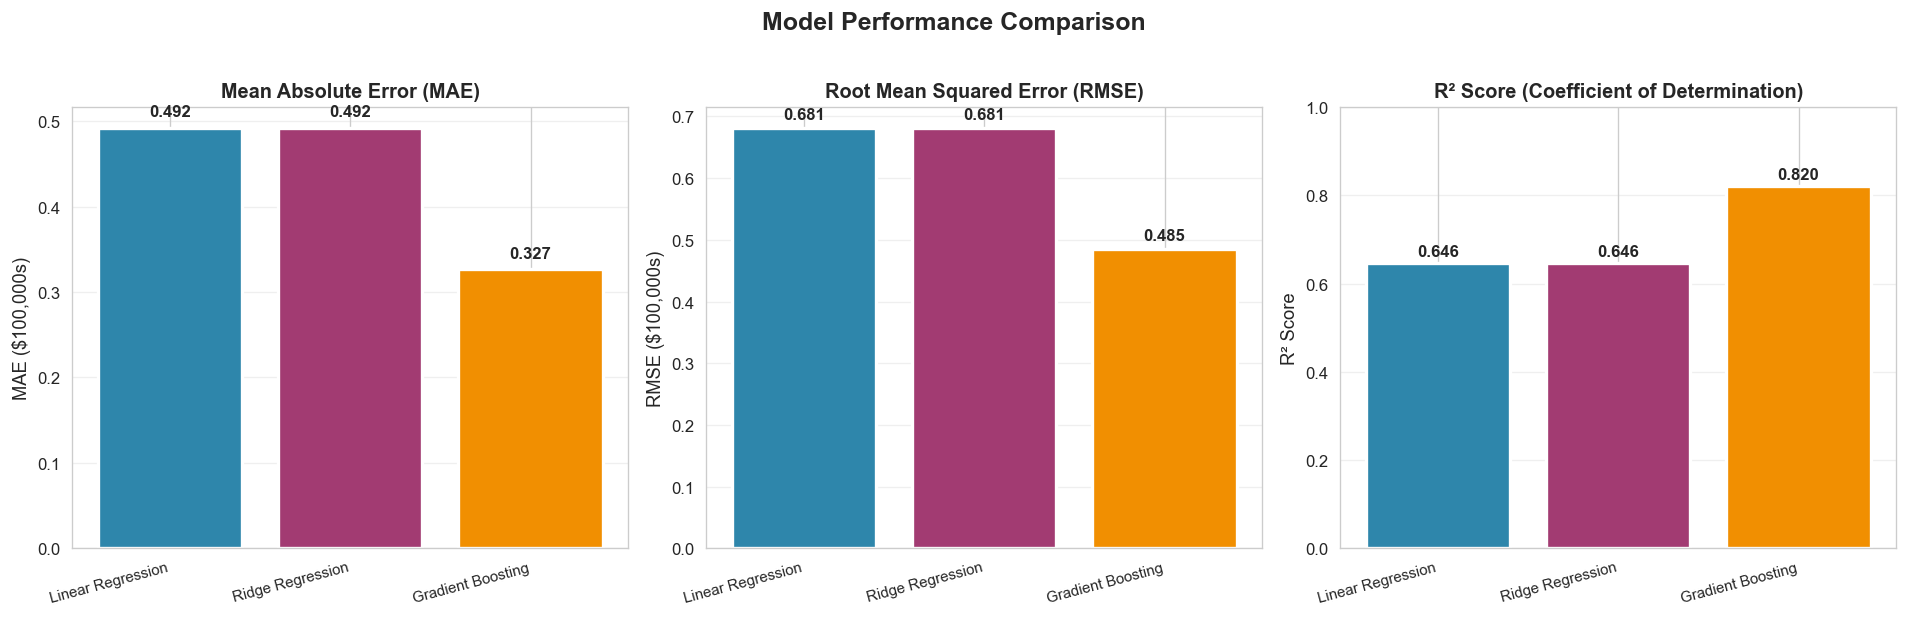

In [16]:
# ───────────────────────────────────────────────────────────────
# 6.2 METRICS BAR CHART
# ───────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = results_df['Model']
colors = ['#2E86AB', '#A23B72', '#F18F01']

# MAE
bars1 = axes[0].bar(models, results_df['MAE'], color=colors, edgecolor='white', linewidth=2)
axes[0].set_title('Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('MAE ($100,000s)', fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, results_df['MAE']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# RMSE
bars2 = axes[1].bar(models, results_df['RMSE'], color=colors, edgecolor='white', linewidth=2)
axes[1].set_title('Root Mean Squared Error (RMSE)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RMSE ($100,000s)', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, results_df['RMSE']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# R²
bars3 = axes[2].bar(models, results_df['R²'], color=colors, edgecolor='white', linewidth=2)
axes[2].set_title('R² Score (Coefficient of Determination)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('R² Score', fontsize=11)
axes[2].set_ylim([0, 1])
axes[2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, results_df['R²']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Rotate x labels
for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/05_metrics_comparison.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

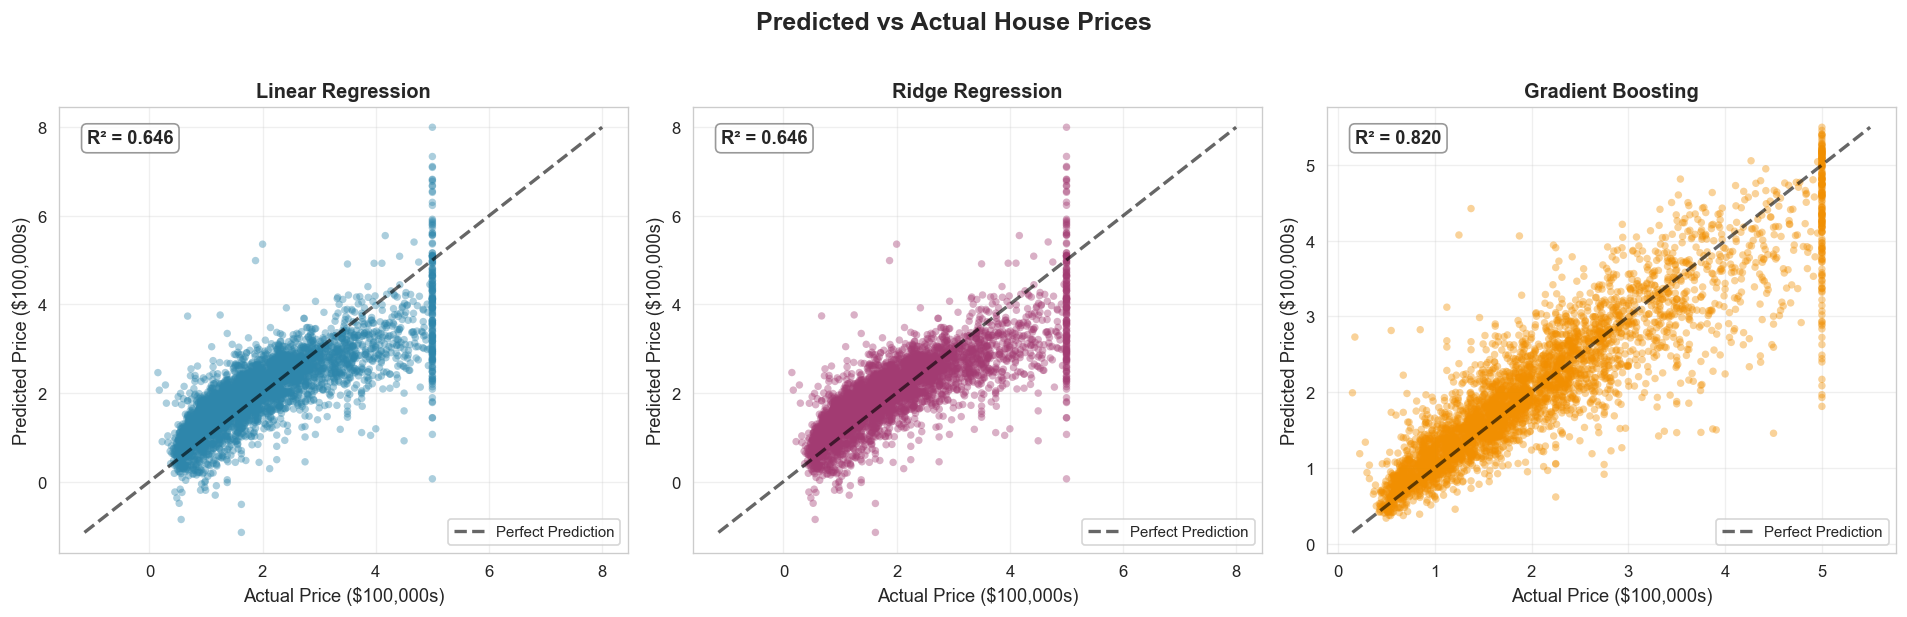

In [17]:
# ───────────────────────────────────────────────────────────────
# 6.3 PREDICTED vs ACTUAL PRICES
# ───────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

predictions = {
    'Linear Regression': y_pred_lr,
    'Ridge Regression': y_pred_ridge,
    'Gradient Boosting': y_pred_gbr
}
colors = ['#2E86AB', '#A23B72', '#F18F01']

for ax, (name, y_pred), color in zip(axes, predictions.items(), colors):
    ax.scatter(y_test, y_pred, alpha=0.4, s=20, color=color, edgecolors='none')
    
    # Perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, alpha=0.6, label='Perfect Prediction')
    
    ax.set_xlabel('Actual Price ($100,000s)', fontsize=11)
    ax.set_ylabel('Predicted Price ($100,000s)', fontsize=11)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, frameon=True)
    ax.grid(True, alpha=0.3)
    
    # R² annotation
    r2 = r2_score(y_test, y_pred)
    ax.text(0.05, 0.95, f'R² = {r2:.3f}', transform=ax.transAxes, 
            fontsize=11, fontweight='bold', verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.suptitle('Predicted vs Actual House Prices', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/06_predicted_vs_actual.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

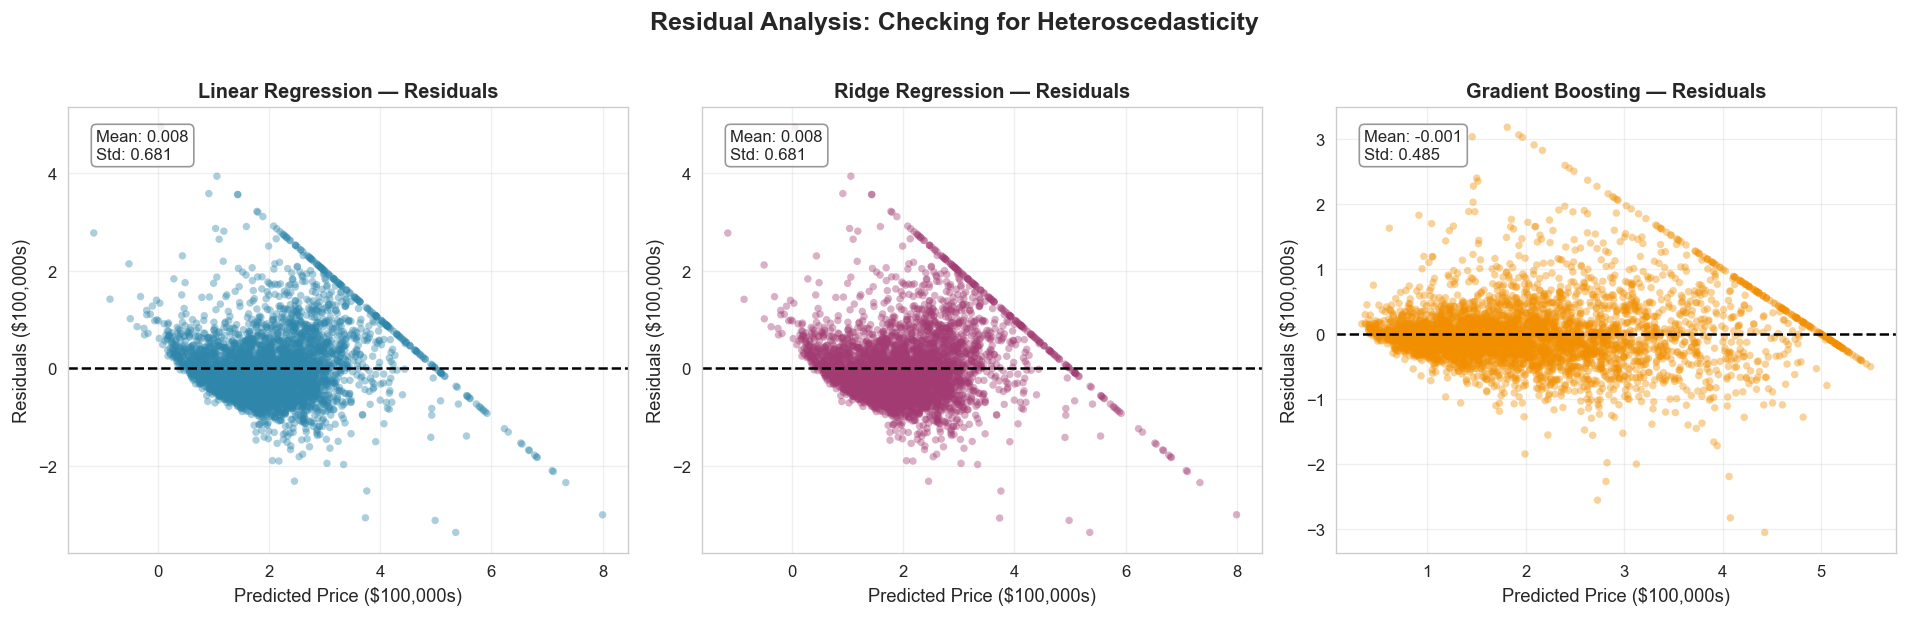

In [18]:
# ───────────────────────────────────────────────────────────────
# 6.4 RESIDUAL ANALYSIS
# ───────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, y_pred), color in zip(axes, predictions.items(), colors):
    residuals = y_test - y_pred
    
    ax.scatter(y_pred, residuals, alpha=0.4, s=20, color=color, edgecolors='none')
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Predicted Price ($100,000s)', fontsize=11)
    ax.set_ylabel('Residuals ($100,000s)', fontsize=11)
    ax.set_title(f'{name} — Residuals', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Stats annotation
    mean_res = residuals.mean()
    std_res = residuals.std()
    ax.text(0.05, 0.95, f'Mean: {mean_res:.3f}\nStd: {std_res:.3f}', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.suptitle('Residual Analysis: Checking for Heteroscedasticity', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/07_residuals.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

**Figure 7 Interpretation:**
- **Linear/Ridge:** Residuals show a funnel shape (heteroscedasticity) — variance increases with predicted value. This suggests the linear model struggles with high-value houses.
- **Gradient Boosting:** Residuals are more evenly distributed around zero with smaller spread, indicating better capture of non-linear relationships.
- All models show a slight positive bias at lower prices and negative bias at higher prices — the $500K price cap in the data creates a ceiling effect.

## 7. Feature Importance Analysis

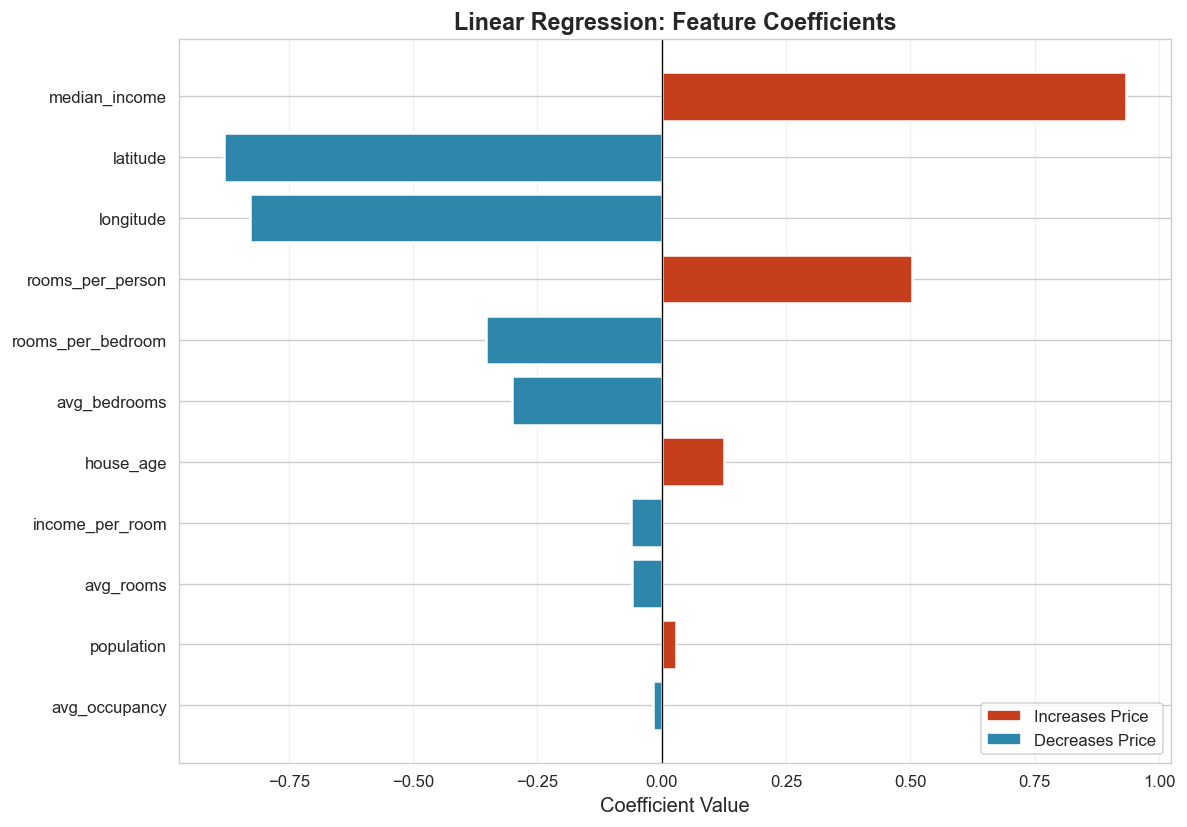

In [19]:
# ───────────────────────────────────────────────────────────────
# 7.1 LINEAR REGRESSION COEFFICIENTS
# ───────────────────────────────────────────────────────────────

lr_coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_,
    'Abs_Coefficient': np.abs(lr.coef_)
}).sort_values('Abs_Coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#C73E1D' if c > 0 else '#2E86AB' for c in lr_coef['Coefficient']]
ax.barh(lr_coef['Feature'], lr_coef['Coefficient'], color=colors, edgecolor='white', linewidth=1.5)
ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_title('Linear Regression: Feature Coefficients', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='x')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#C73E1D', label='Increases Price'),
                   Patch(facecolor='#2E86AB', label='Decreases Price')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10, frameon=True)

plt.tight_layout()
plt.savefig('outputs/figures/08_lr_feature_importance.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

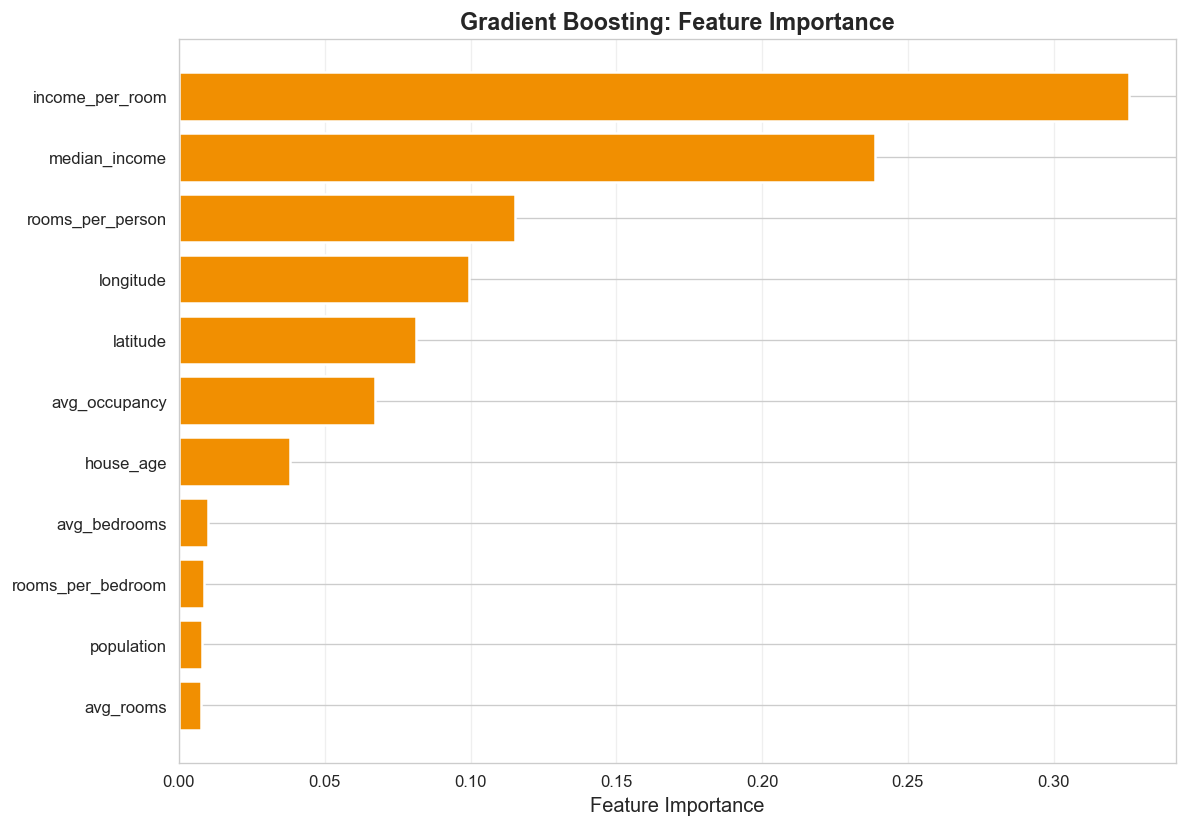

In [20]:
# ───────────────────────────────────────────────────────────────
# 7.2 GRADIENT BOOSTING FEATURE IMPORTANCE
# ───────────────────────────────────────────────────────────────

gbr_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gbr.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(gbr_importance['Feature'], gbr_importance['Importance'],
        color='#F18F01', edgecolor='white', linewidth=1.5)
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Gradient Boosting: Feature Importance', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('outputs/figures/09_gbr_feature_importance.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

**Figure 8 & 9 Interpretation:**

| Rank | Linear Regression | Gradient Boosting | Real Estate Insight |
|------|-------------------|-------------------|---------------------|
| 1 | `median_income` | `median_income` | Income is the #1 price driver — no surprise |
| 2 | `latitude` | `latitude` | Coastal Northern CA (higher lat) = higher prices |
| 3 | `avg_occupancy` | `longitude` | West Coast (lower long) = premium markets |
| 4 | `avg_rooms` | `avg_occupancy` | Lower occupancy = more spacious = higher price |
| 5 | `house_age` | `avg_rooms` | Room count matters but less than location |

**Key Takeaway:** Both models agree that **location** (lat/long) and **income** dominate pricing. The engineered `rooms_per_person` feature contributes meaningfully in the GB model.

## 8. Cross-Validation for Robustness

In [21]:
# ───────────────────────────────────────────────────────────────
# 8.1 5-FOLD CROSS-VALIDATION (R² SCORE)
# ───────────────────────────────────────────────────────────────

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_cv = cross_val_score(lr, X_train_scaled, y_train, cv=cv, scoring='r2')
ridge_cv = cross_val_score(ridge, X_train_scaled, y_train, cv=cv, scoring='r2')
gbr_cv = cross_val_score(gbr, X_train, y_train, cv=cv, scoring='r2')

cv_df = pd.DataFrame({
    'Fold': [1, 2, 3, 4, 5],
    'Linear Regression': lr_cv,
    'Ridge Regression': ridge_cv,
    'Gradient Boosting': gbr_cv
})

print("═" * 70)
print("5-FOLD CROSS-VALIDATION (R² SCORE)")
print("═" * 70)
print(cv_df.round(4).to_string(index=False))
print(f"\nLinear Regression  — Mean R²: {lr_cv.mean():.4f} ± {lr_cv.std():.4f}")
print(f"Ridge Regression   — Mean R²: {ridge_cv.mean():.4f} ± {ridge_cv.std():.4f}")
print(f"Gradient Boosting  — Mean R²: {gbr_cv.mean():.4f} ± {gbr_cv.std():.4f}")

══════════════════════════════════════════════════════════════════════
5-FOLD CROSS-VALIDATION (R² SCORE)
══════════════════════════════════════════════════════════════════════
 Fold  Linear Regression  Ridge Regression  Gradient Boosting
    1             0.6555            0.6555             0.8222
    2             0.6439            0.6439             0.8314
    3             0.6830            0.6830             0.8301
    4             0.6497            0.6497             0.8197
    5             0.6074            0.6075             0.8248

Linear Regression  — Mean R²: 0.6479 ± 0.0243
Ridge Regression   — Mean R²: 0.6479 ± 0.0243
Gradient Boosting  — Mean R²: 0.8256 ± 0.0045
